In [25]:
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

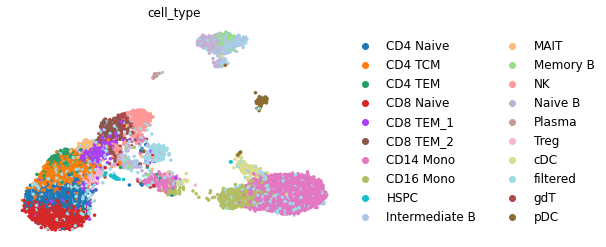

In [6]:
# Human Blood
data = pd.read_csv('../data/tissue_specific_data/ProcessedData/Human-Blood/expression.csv', index_col=0)
data = data.transpose() # cell * gene

cell_type = pd.read_csv('../data/tissue_specific_data/RawData/Human-Blood/cell_type.csv', index_col=0)
cell_type = cell_type['celltype']

adata = sc.AnnData(data, dtype='float64')
adata.obs['cell_type'] = cell_type
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40, use_rep='X')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], s=50, frameon=False, legend_fontsize=12, show=False)
plt.savefig('./_figure/tissue_cell_type_tsne/Human-Blood-Raw.pdf', bbox_inches='tight')

/home/lijiawei/.local/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


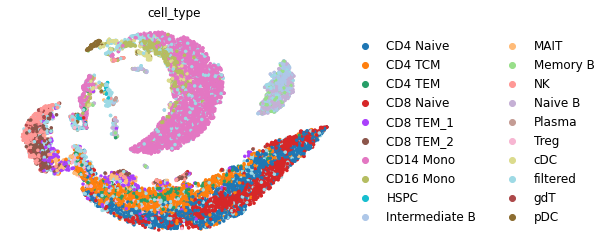

: 

In [30]:
# Human Blood Aggregation
data = pd.read_csv('../data/tissue_specific_data/ProcessedData/Human-Blood/expression.csv', index_col=0) # gene * cell
data = data.transpose() # cell * gene
corr = data.corr('spearman') # gene * gene
corr_pos = corr > 0.2 # gene * gene
corr_neg = corr < -0.2 # gene * gene
corr_pos = corr_pos.astype(int) # gene * gene
corr_neg = corr_neg.astype(int) # gene * gene
corr = corr_pos - corr_neg

# Aggregation
corr = corr.to_numpy() # gene * gene

degrees = np.sum(corr, axis=0) # gene
# where degrees == 0, set to 1
degrees[degrees == 0] = 1
data_ = data.to_numpy() # cell * gene
data_ = np.matmul(data_, corr) # cell * gene
data_ = data_ / degrees # cell * gene
data.values[:] = data_ # cell * gene

# save the aggregated data
# data.to_csv('./Human-Blood-Aggregation.csv')


cell_type = pd.read_csv('../data/tissue_specific_data/RawData/Human-Blood/cell_type.csv', index_col=0)
cell_type = cell_type['celltype']

adata = sc.AnnData(data, dtype='float64')
adata.obs['cell_type'] = cell_type
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40, use_rep='X')
# sc.tl.umap(adata)
# sc.pl.umap(adata, color=['cell_type'], s=50, frameon=False, legend_fontsize=12, show=False)
sc.tl.tsne(adata, use_rep='X')
sc.pl.tsne(adata, color=['cell_type'], s=50, frameon=False, legend_fontsize=12, show=False)
plt.savefig('./_figure/tissue_cell_type_tsne/Human-Blood-Aggregation.pdf', bbox_inches='tight')

In [29]:
from sklearn import manifold

# manifold tsne
manifold.TSNE

Help on function tsne in module scanpy.plotting._tools.scatterplots:

tsne(adata: anndata._core.anndata.AnnData, *, color: Union[str, Sequence[str], NoneType] = None, gene_symbols: Optional[str] = None, use_raw: Optional[bool] = None, sort_order: bool = True, edges: bool = False, edges_width: float = 0.1, edges_color: Union[str, Sequence[float], Sequence[str]] = 'grey', neighbors_key: Optional[str] = None, arrows: bool = False, arrows_kwds: Optional[Mapping[str, Any]] = None, groups: Optional[str] = None, components: Union[str, Sequence[str]] = None, dimensions: Union[Tuple[int, int], Sequence[Tuple[int, int]], NoneType] = None, layer: Optional[str] = None, projection: Literal['2d', '3d'] = '2d', scale_factor: Optional[float] = None, color_map: Union[matplotlib.colors.Colormap, str, NoneType] = None, cmap: Union[matplotlib.colors.Colormap, str, NoneType] = None, palette: Union[str, Sequence[str], cycler.Cycler, NoneType] = None, na_color: Union[str, Tuple[float, ...]] = 'lightgray', na